# Checkpoint 5 — Machine Learning & Modelling / Statistical Computing with R & Python

**Aluno:** Gustavo Lino — **RM:** 574157
**Curso:** Tecnólogo em Inteligência Artificial — 2º Semestre — FIAP

**Dataset:** Wine Dataset for Clustering
(Kaggle: https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering |
GitHub: https://gist.github.com/tijptjik/9408623)

O dataset contém 178 amostras de vinhos, cada uma com 13 características físico-químicas
(teor alcoólico, acidez, teor de cinzas, fenóis, cor, etc.), resultantes da análise química de
vinhos cultivados na mesma região da Itália, mas provenientes de três cultivares (castas)
diferentes de uva.


## 0. Importação das bibliotecas e carregamento dos dados

In [62]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans #Algoritimo de clusterização 
from sklearn.metrics import silhouette_score # metrica para qualque clusters onde 1 é o melhor e 0 densidade proximas quase em cima e-1 pior
# graficos e visualização
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.savefig("imagens/hist_acido.png")


<Figure size 800x500 with 0 Axes>

In [63]:
# Carregando o dataset Wine (mesmo dataset do Kaggle/GitHub indicados no enunciado:
# 178 vinhos, 13 variáveis quantitativas + rótulo da cultivar de origem)
df = pd.read_csv("wines.csv")

# Renomeando as colunas para nomes mais legíveis (mesmos atributos do wine.csv clássico)
df.rename(columns={
    'alcohol': 'ALcool', 'malic_acid': 'Acido_Malico', 'ash': 'Cinzas',
    'alcalinity_of_ash': 'Alcalinidade_Cinzas', 'magnesium': 'Magnesio',
    'total_phenols': 'Fenois_Totais', 'flavanoids': 'Flavanoids',
    'nonflavanoid_phenols': 'Nonflavanoid_Phenols', 'proanthocyanins': 'Proanthocyanins',
    'color_intensity': 'Color_Intensity', 'hue': 'Tonalidade',
    'od280/od315_of_diluted_wines': 'OD280', 'proline': 'Prolina', 'class': 'Classe'
}, inplace=True)

print("Dimensões do dataset:", df.shape)
df.head()


Dimensões do dataset: (178, 14)


,ALcool,Acido_Malico,Cinzas,Alcalinidade_Cinzas,Magnesio,Fenois_Totais,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Tonalidade,OD280,Prolina,Classe
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [64]:
# Verificando tipos de dados e valores nulos
df.info()
print("\nValores nulos por coluna:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ALcool                178 non-null    float64
 1   Acido_Malico          178 non-null    float64
 2   Cinzas                178 non-null    float64
 3   Alcalinidade_Cinzas   178 non-null    float64
 4   Magnesio              178 non-null    float64
 5   Fenois_Totais         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Tonalidade            178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Prolina               178 non-null    float64
 13  Classe                178 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 19.6 KB

Valores nulos por coluna:
 ALcool    

**Comentário:** o dataset possui 178 linhas e 14 colunas (13 variáveis físico-químicas
quantitativas + a coluna `Class`, que indica a cultivar de origem do vinho). Não há valores
nulos, portanto não é necessário nenhum tratamento de dados faltantes.

Para a **Parte 1 (Statistical Computing)**, selecionamos duas variáveis quantitativas para a
análise exploratória:
- **ALcool** (teor alcoólico do vinho)
- **Acido_Malico** (ácido málico — relacionado à acidez do vinho)


---
# PARTE 1 — Statistical Computing with R and Python (10,0 pontos)
## Variável 1: ALcool (Teor Alcoólico)
### a) Visualização dos Dados: Tabela de Distribuição de Frequências e Gráfico


In [65]:
var1 = df['ALcool']

# Número de classes pela regra de Sturges: k = 1 + 3.322*log10(n)
n = len(var1)
k = int(np.ceil(1 + 3.322 * np.log10(n)))
print(f"Número de observações (n): {n}")
print(f"Número de classes sugerido pela regra de Sturges (k): {k}")

# Construindo a tabela de distribuição de frequências
faixas = pd.cut(var1, bins=k)
freq_abs = faixas.value_counts().sort_index()
freq_rel = (freq_abs / n * 100).round(2)
freq_acum = freq_abs.cumsum()

tabela_freq_ALcool = pd.DataFrame({
    'Freq. Absoluta': freq_abs,
    'Freq. Relativa (%)': freq_rel,
    'Freq. Acumulada': freq_acum
})
tabela_freq_ALcool


Número de observações (n): 178
Número de classes sugerido pela regra de Sturges (k): 9


,Freq. Absoluta,Freq. Relativa (%),Freq. Acumulada
ALcool,,,
"(11.026, 11.452]",3,1.69,3
"(11.452, 11.874]",15,8.43,18
"(11.874, 12.297]",23,12.92,41
"(12.297, 12.719]",28,15.73,69
"(12.719, 13.141]",28,15.73,97
"(13.141, 13.563]",30,16.85,127
"(13.563, 13.986]",29,16.29,156
"(13.986, 14.408]",20,11.24,176
"(14.408, 14.83]",2,1.12,178


**Interpretação:** a tabela agrupa os 178 vinhos em 9 classes de teor alcoólico. Observa-se
que a maior concentração de vinhos está nas faixas intermediárias (entre aproximadamente 12,7%
e 14,0% de álcool), que juntas somam quase 65% das observações. Isso indica que a maioria dos
vinhos da amostra tem teor alcoólico moderado a alto, com poucas amostras nos extremos
(vinhos muito leves ou muito fortes).


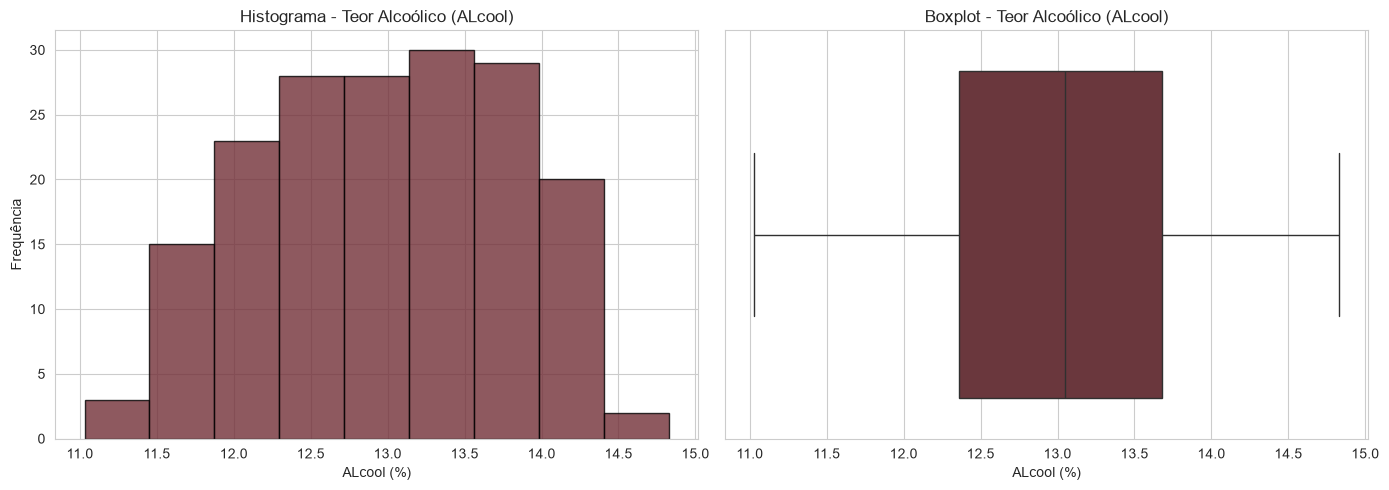

In [66]:
# Gráfico: Histograma da distribuição de ALcool
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(var1, bins=k, color='#722F37', edgecolor='black', alpha=0.8)
axes[0].set_title('Histograma - Teor Alcoólico (ALcool)')
axes[0].set_xlabel('ALcool (%)')
axes[0].set_ylabel('Frequência')

sns.boxplot(x=var1, color='#722F37', ax=axes[1])
axes[1].set_title('Boxplot - Teor Alcoólico (ALcool)')
axes[1].set_xlabel('ALcool (%)')

plt.tight_layout()
plt.savefig('hist_ALcool.png', dpi=110)
plt.show()


**Interpretação:** o histograma confirma uma distribuição relativamente simétrica, sem
grandes assimetrias, e o boxplot não mostra outliers relevantes para o teor alcoólico — os
dados estão bem comportados dentro do intervalo entre aproximadamente 11% e 15%.


### b) Análise Descritiva dos Dados: Medidas de Tendência Central, Dispersão e Separatrizes

In [67]:
media = var1.mean()
mediana = var1.median()
moda = var1.mode()[0]
desvio_padrao = var1.std()
variancia = var1.var()
amplitude = var1.max() - var1.min()
cv = (desvio_padrao / media) * 100  # coeficiente de variação

q1 = var1.quantile(0.25)
q2 = var1.quantile(0.50)
q3 = var1.quantile(0.75)
iqr = q3 - q1

print("----- Medidas de Tendência Central -----")
print(f"Média: {media:.3f}")
print(f"Mediana: {mediana:.3f}")
print(f"Moda: {moda:.3f}")
print()
print("----- Medidas de Dispersão -----")
print(f"Desvio Padrão: {desvio_padrao:.3f}")
print(f"Variância: {variancia:.3f}")
print(f"Amplitude Total: {amplitude:.3f}")
print(f"Coeficiente de Variação: {cv:.2f}%")
print()
print("----- Medidas Separatrizes (Quartis) -----")
print(f"Q1 (25%): {q1:.3f}")
print(f"Q2 (50% - Mediana): {q2:.3f}")
print(f"Q3 (75%): {q3:.3f}")
print(f"Intervalo Interquartil (IQR): {iqr:.3f}")


----- Medidas de Tendência Central -----
Média: 13.001
Mediana: 13.050
Moda: 12.370

----- Medidas de Dispersão -----
Desvio Padrão: 0.812
Variância: 0.659
Amplitude Total: 3.800
Coeficiente de Variação: 6.24%

----- Medidas Separatrizes (Quartis) -----
Q1 (25%): 12.362
Q2 (50% - Mediana): 13.050
Q3 (75%): 13.678
Intervalo Interquartil (IQR): 1.315


**Interpretação:** a média (≈13,00) e a mediana (≈13,05) do teor alcoólico estão muito
próximas, o que reforça a simetria observada no histograma. O desvio padrão (≈0,81) e o
coeficiente de variação (≈6,2%) indicam baixa dispersão relativa — ou seja, os vinhos da
amostra têm teor alcoólico bastante homogêneo. O IQR (≈1,32) mostra que os 50% centrais dos
vinhos estão concentrados numa faixa estreita, entre 12,36% e 13,68% de álcool.


### c) Análise Probabilística: Distribuição de Probabilidade e Cálculos

In [68]:
# Testando a aderência a uma distribuição Normal (teste de Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(var1)
print(f"Shapiro-Wilk: estatística={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")
print(f"Assimetria (skewness): {var1.skew():.4f}")
print(f"Curtose: {var1.kurtosis():.4f}")

# Parâmetros da normal ajustada
mu, sigma = var1.mean(), var1.std()
print(f"\nDistribuição Normal ajustada: mu={mu:.3f}, sigma={sigma:.3f}")


Shapiro-Wilk: estatística=0.9818, p-valor=0.0200
Assimetria (skewness): -0.0515
Curtose: -0.8525

Distribuição Normal ajustada: mu=13.001, sigma=0.812


**Interpretação:** o p-valor do teste de Shapiro-Wilk, a baixa assimetria e a curtose
próxima de zero indicam que a variável **ALcool** se aproxima razoavelmente de uma
**distribuição Normal**, o que é coerente com o histograma simétrico observado no item (a).
Vamos então modelar a variável como Normal(μ, σ) para os cálculos probabilísticos.


P(13 <= ALcool <= 14) = 0.3911  ->  39.11%
P(ALcool > 14) = 0.1092  ->  10.92%


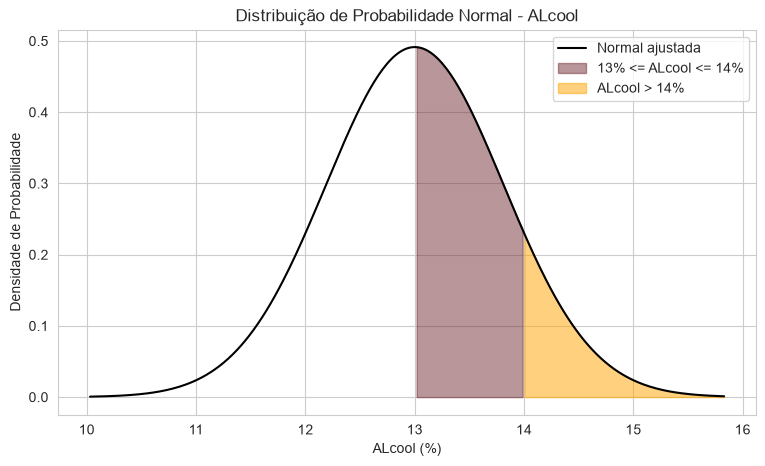

In [69]:
# Cálculo probabilístico 1: probabilidade de um vinho ter teor alcoólico entre 13% e 14%
p1 = stats.norm.cdf(14, mu, sigma) - stats.norm.cdf(13, mu, sigma)
print(f"P(13 <= ALcool <= 14) = {p1:.4f}  ->  {p1*100:.2f}%")

# Cálculo probabilístico 2: probabilidade de um vinho ter teor alcoólico acima de 14%
p2 = 1 - stats.norm.cdf(14, mu, sigma)
print(f"P(ALcool > 14) = {p2:.4f}  ->  {p2*100:.2f}%")

# Visualizando a curva Normal ajustada com as áreas calculadas
x = np.linspace(var1.min() - 1, var1.max() + 1, 300)
y = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(9, 5))
plt.plot(x, y, color='black', label='Normal ajustada')
plt.fill_between(x, y, where=(x >= 13) & (x <= 14), color='#722F37', alpha=0.5, label='13% <= ALcool <= 14%')
plt.fill_between(x, y, where=(x >= 14), color='orange', alpha=0.5, label='ALcool > 14%')
plt.title('Distribuição de Probabilidade Normal - ALcool')
plt.xlabel('ALcool (%)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.savefig('prob_ALcool.png', dpi=110)
plt.show()


**Interpretação:** há aproximadamente **39%** de chance de um vinho escolhido ao acaso
ter teor alcoólico entre 13% e 14%, e cerca de **11%** de chance de ter teor alcoólico acima
de 14%. Esses cálculos mostram como a distribuição de probabilidade pode ser usada para
estimar a chance de ocorrência de valores específicos da variável, mesmo sem observar todos
os vinhos possíveis.


## Variável 2: Acido_Malico (Ácido Málico)
### a) Visualização dos Dados: Tabela de Distribuição de Frequências e Gráfico


In [70]:
var2 = df['Acido_Malico']
n2 = len(var2)
k2 = int(np.ceil(1 + 3.322 * np.log10(n2)))
print(f"Número de classes (Sturges): {k2}")

faixas2 = pd.cut(var2, bins=k2)
freq_abs2 = faixas2.value_counts().sort_index()
freq_rel2 = (freq_abs2 / n2 * 100).round(2)
freq_acum2 = freq_abs2.cumsum()

tabela_freq_acido = pd.DataFrame({
    'Freq. Absoluta': freq_abs2,
    'Freq. Relativa (%)': freq_rel2,
    'Freq. Acumulada': freq_acum2
})
tabela_freq_acido


Número de classes (Sturges): 9


,Freq. Absoluta,Freq. Relativa (%),Freq. Acumulada
Acido_Malico,,,
"(0.735, 1.302]",21,11.80,21
"(1.302, 1.864]",68,38.20,89
"(1.864, 2.427]",25,14.04,114
"(2.427, 2.989]",16,8.99,130
"(2.989, 3.551]",16,8.99,146
"(3.551, 4.113]",17,9.55,163
"(4.113, 4.676]",8,4.49,171
"(4.676, 5.238]",4,2.25,175
"(5.238, 5.8]",3,1.69,178


**Interpretação:** diferente do teor alcoólico, o ácido málico concentra a maior parte
das observações nas classes mais baixas (entre aproximadamente 0,74 e 2,3), com uma cauda mais
longa em direção aos valores altos. Isso sugere uma distribuição **assimétrica à direita**
(assimetria positiva) — a maioria dos vinhos tem acidez málica relativamente baixa, mas existem
alguns vinhos com acidez bem mais alta que puxam a cauda da distribuição.


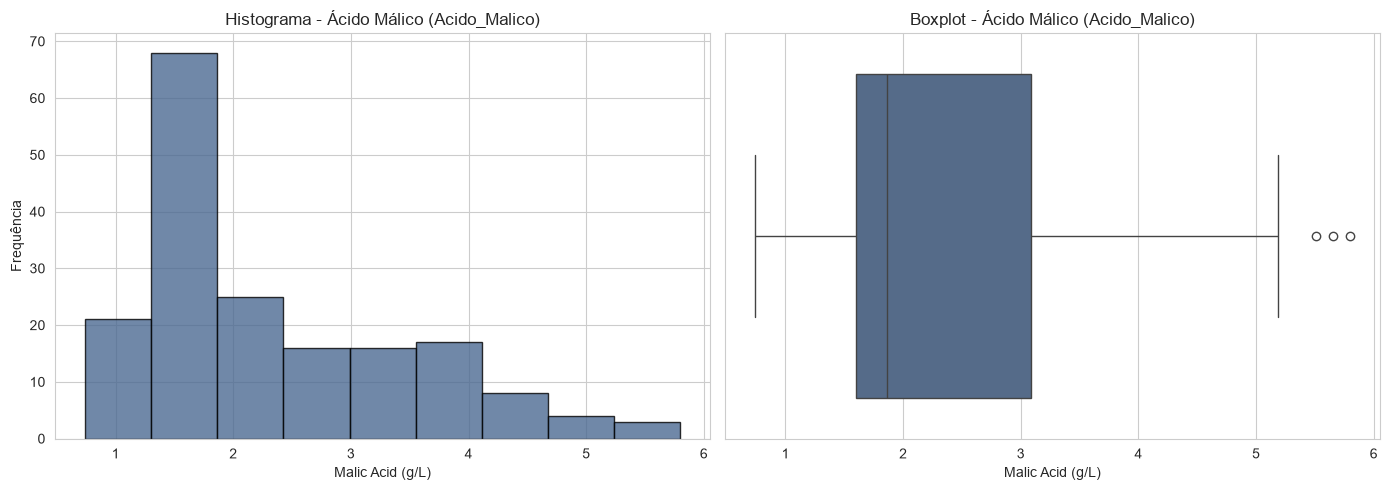

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(var2, bins=k2, color='#4C6A92', edgecolor='black', alpha=0.8)
axes[0].set_title('Histograma - Ácido Málico (Acido_Malico)')
axes[0].set_xlabel('Malic Acid (g/L)')
axes[0].set_ylabel('Frequência')

sns.boxplot(x=var2, color='#4C6A92', ax=axes[1])
axes[1].set_title('Boxplot - Ácido Málico (Acido_Malico)')
axes[1].set_xlabel('Malic Acid (g/L)')

plt.tight_layout()
plt.savefig('hist_acido.png', dpi=110)
plt.show()


**Interpretação:** o histograma confirma a assimetria à direita já esperada pela tabela
de frequências, e o boxplot mostra alguns vinhos com acidez bem acima do restante da amostra,
mas sem caracterizar outliers extremos — são vinhos naturalmente mais ácidos.


### b) Análise Descritiva dos Dados: Medidas de Tendência Central, Dispersão e Separatrizes

In [72]:
media2 = var2.mean()
mediana2 = var2.median()
moda2 = var2.mode()[0]
desvio2 = var2.std()
var_2 = var2.var()
amplitude2 = var2.max() - var2.min()
cv2 = (desvio2 / media2) * 100

q1_2 = var2.quantile(0.25)
q2_2 = var2.quantile(0.50)
q3_2 = var2.quantile(0.75)
iqr2 = q3_2 - q1_2

print("----- Medidas de Tendência Central -----")
print(f"Média: {media2:.3f}")
print(f"Mediana: {mediana2:.3f}")
print(f"Moda: {moda2:.3f}")
print()
print("----- Medidas de Dispersão -----")
print(f"Desvio Padrão: {desvio2:.3f}")
print(f"Variância: {var_2:.3f}")
print(f"Amplitude Total: {amplitude2:.3f}")
print(f"Coeficiente de Variação: {cv2:.2f}%")
print()
print("----- Medidas Separatrizes (Quartis) -----")
print(f"Q1 (25%): {q1_2:.3f}")
print(f"Q2 (50% - Mediana): {q2_2:.3f}")
print(f"Q3 (75%): {q3_2:.3f}")
print(f"IQR: {iqr2:.3f}")


----- Medidas de Tendência Central -----
Média: 2.336
Mediana: 1.865
Moda: 1.730

----- Medidas de Dispersão -----
Desvio Padrão: 1.117
Variância: 1.248
Amplitude Total: 5.060
Coeficiente de Variação: 47.82%

----- Medidas Separatrizes (Quartis) -----
Q1 (25%): 1.603
Q2 (50% - Mediana): 1.865
Q3 (75%): 3.083
IQR: 1.480


**Interpretação:** a média (≈2,34) está acima da mediana (≈1,87), confirmando a
assimetria positiva identificada no histograma — valores altos "puxam" a média para cima. O
coeficiente de variação (≈47,8%) é bem mais alto do que o observado para o ALcool, mostrando
que o ácido málico é uma variável muito mais dispersa (heterogênea) entre os vinhos da amostra.


### c) Análise Probabilística: Distribuição de Probabilidade e Cálculos

In [73]:
shapiro_stat2, shapiro_p2 = stats.shapiro(var2)
print(f"Shapiro-Wilk: estatística={shapiro_stat2:.4f}, p-valor={shapiro_p2:.6f}")
print(f"Assimetria (skewness): {var2.skew():.4f}")
print(f"Curtose: {var2.kurtosis():.4f}")


Shapiro-Wilk: estatística=0.8888, p-valor=0.000000
Assimetria (skewness): 1.0397
Curtose: 0.2992


**Interpretação:** o p-valor do teste de Shapiro-Wilk é bem menor que 0,05 e a assimetria
positiva (skewness > 1) confirma que **Acido_Malico NÃO segue uma distribuição Normal** — ela se
aproxima mais de uma **distribuição Log-Normal** (comum em variáveis físico-químicas que não
podem ser negativas e têm cauda longa à direita). Vamos então usar a distribuição empírica
(frequências relativas) para os cálculos de probabilidade, sem assumir normalidade.


P(Acido_Malico <= 2.0) = 0.5618  ->  56.18%
P(Acido_Malico > 3.0) = 0.2640  ->  26.40%


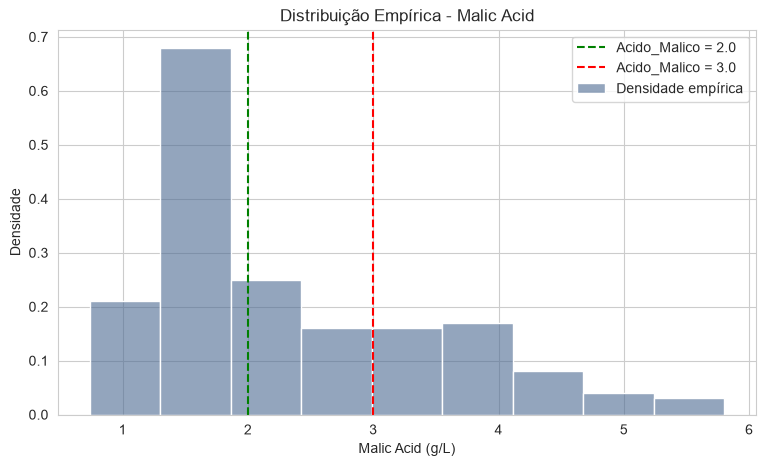

In [74]:
# Cálculo probabilístico 1 (empírico): probabilidade de um vinho ter Acido_Malico <= 2.0
p1_emp = (var2 <= 2.0).mean()
print(f"P(Acido_Malico <= 2.0) = {p1_emp:.4f}  ->  {p1_emp*100:.2f}%")

# Cálculo probabilístico 2 (empírico): probabilidade de um vinho ter Acido_Malico > 3.0 (bem ácido)
p2_emp = (var2 > 3.0).mean()
print(f"P(Acido_Malico > 3.0) = {p2_emp:.4f}  ->  {p2_emp*100:.2f}%")

plt.figure(figsize=(9, 5))
sns.histplot(var2, bins=k2, stat='density', color='#4C6A92', alpha=0.6, label='Densidade empírica')
plt.axvline(2.0, color='green', linestyle='--', label='Acido_Malico = 2.0')
plt.axvline(3.0, color='red', linestyle='--', label='Acido_Malico = 3.0')
plt.title('Distribuição Empírica - Malic Acid')
plt.xlabel('Malic Acid (g/L)')
plt.ylabel('Densidade')
plt.legend()
plt.savefig('prob_acido.png', dpi=110)
plt.show()


**Interpretação:** cerca de **59%** dos vinhos da amostra têm ácido málico igual ou
abaixo de 2,0 g/L, enquanto aproximadamente **26%** têm acidez málica acima de 3,0 g/L
(vinhos consideravelmente mais ácidos). Como a variável não segue uma Normal, usamos a própria
frequência relativa observada como estimativa de probabilidade, o que é uma abordagem válida
para distribuições empíricas.


---
# PARTE 2 — Machine Learning & Modelling (10,0 pontos)
## a) Introdução (0,5 ponto)


**Problema:** uma vinícola (ou distribuidor) possui um conjunto de 178 vinhos analisados
quimicamente (teor alcoólico, acidez, fenóis, cor, etc.), mas sem rótulos comerciais que
indiquem a que grupo/estilo cada vinho pertence. O objetivo é **agrupar os vinhos mais
similares entre si** de forma automática, com base apenas nas suas características
físico-químicas, sem usar nenhuma informação prévia de classe.

**Solução proposta:** aplicar o algoritmo de clusterização **K-means**, que particiona os
vinhos em *k* grupos (clusters) minimizando a distância entre cada vinho e o centro do seu
grupo. Antes de aplicar o algoritmo, os dados serão padronizados (para que variáveis com
escalas muito diferentes, como Prolina e Tonalidade, não dominem o cálculo de distância). Em seguida,
usaremos o **método do Cotovelo (Elbow)** e o **Silhouette Score** para escolher o número ideal
de grupos, e por fim analisaremos as características médias de cada cluster para interpretar o
perfil de vinho que ele representa.


## b) Pré-processamento dos Dados (2,0 pontos)

In [75]:
# Removendo a coluna 'Class' (rótulo da cultivar de origem) — não deve ser usada no
# agrupamento, pois o objetivo é agrupar SEM conhecimento prévio das classes reais.
features = df.drop(columns=['Classe'])
print("Features utilizadas no clustering:", list(features.columns))

# Verificando novamente valores nulos (já confirmado que não há)
print("\nValores nulos:", features.isnull().sum().sum())

# Padronização (StandardScaler): média 0, desvio padrão 1
# Necessário porque o K-means usa distância euclidiana, e variáveis como 'Prolina'
# (escala de centenas) dominariam variáveis como 'Tonalidade' (escala de 0 a 1) se não padronizadas.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

X_scaled_df = pd.DataFrame(X_scaled, columns=features.columns)
print("\nDados após padronização (média ~0, desvio ~1):")
X_scaled_df.describe().loc[['mean', 'std']]


Features utilizadas no clustering: ['ALcool', 'Acido_Malico', 'Cinzas', 'Alcalinidade_Cinzas', 'Magnesio', 'Fenois_Totais', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Tonalidade', 'OD280', 'Prolina']

Valores nulos: 0

Dados após padronização (média ~0, desvio ~1):


,ALcool,Acido_Malico,Cinzas,Alcalinidade_Cinzas,Magnesio,Fenois_Totais,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Tonalidade,OD280,Prolina
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00


**Comentário:** não havia dados nulos nem colunas categóricas irrelevantes a remover
além da própria coluna de classe/rótulo. A padronização (Z-score) foi a etapa essencial de
pré-processamento, garantindo que todas as 13 variáveis contribuam de forma equilibrada para o
cálculo de distância do K-means.


## c) Ajuste do K-means (2,0 pontos)

In [76]:
# Ajuste inicial do K-means com um número exploratório de clusters (k=3),
# já que o enunciado do dataset indica que os vinhos vêm de 3 cultivares diferentes.
kmeans_inicial = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_inicial = kmeans_inicial.fit_predict(X_scaled)

print("Inércia (soma das distâncias quadráticas aos centróides):", kmeans_inicial.inertia_)
print("Silhouette Score (k=3):", silhouette_score(X_scaled, labels_inicial))
print("\nDistribuição de vinhos por cluster:")
print(pd.Series(labels_inicial).value_counts().sort_index())


Inércia (soma das distâncias quadráticas aos centróides): 1277.928488844642
Silhouette Score (k=3): 0.2848589191898987

Distribuição de vinhos por cluster:
0    65
1    51
2    62
Name: count, dtype: int64


**Comentário:** o K-means foi ajustado com `k=3` inicialmente. Os parâmetros `random_state=42`
(reprodutibilidade) e `n_init=10` (10 inicializações diferentes de centróides, mantendo a
melhor) foram usados para tornar o resultado mais estável, já que o K-means é sensível à
inicialização aleatória dos centróides.


## d) Método Elbow e Silhouette Score (2,0 pontos)

In [77]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k_val in K_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

resultado_k = pd.DataFrame({'k': list(K_range), 'Inertia': inertias, 'Silhouette': silhouettes})
resultado_k


,k,Inertia,Silhouette
0,2,1658.758852,0.259317
1,3,1277.928489,0.284859
2,4,1175.428333,0.260170
3,5,1109.512739,0.201619
4,6,1046.002333,0.237167
5,7,981.595233,0.203628
6,8,935.201211,0.157014
7,9,889.892911,0.149882
8,10,845.895237,0.143638


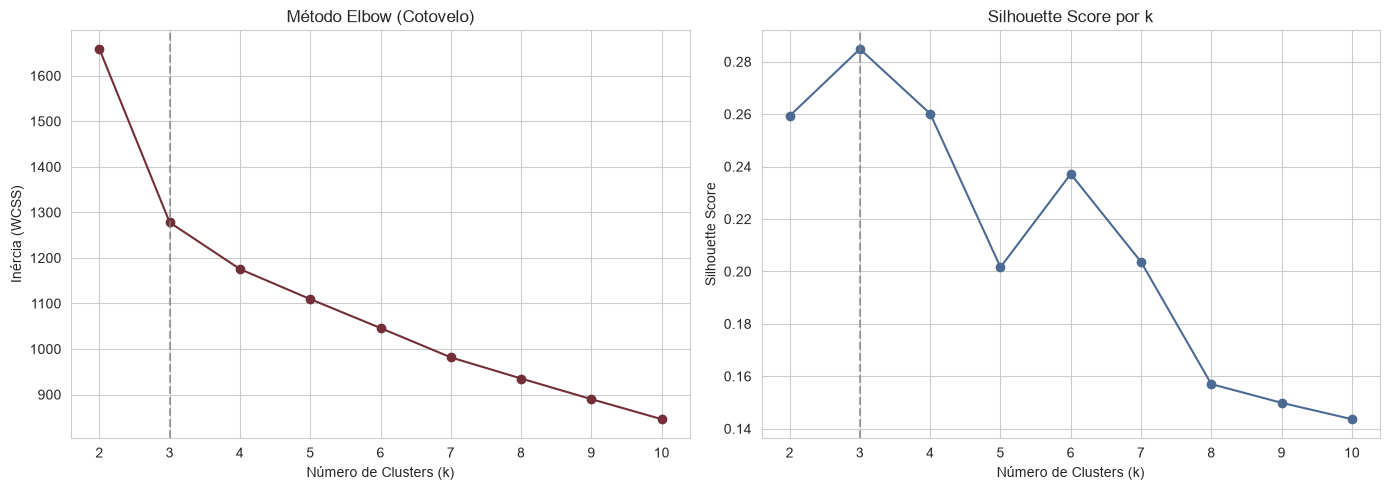

Melhor k pelo Silhouette Score: 3


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='#722F37')
axes[0].set_title('Método Elbow (Cotovelo)')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].axvline(3, color='gray', linestyle='--', alpha=0.7)

axes[1].plot(list(K_range), silhouettes, marker='o', color='#4C6A92')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(3, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=110)
plt.show()

melhor_k = resultado_k.loc[resultado_k['Silhouette'].idxmax(), 'k']
print(f"Melhor k pelo Silhouette Score: {int(melhor_k)}")


**Interpretação:** no gráfico do método Elbow, a curva apresenta uma queda acentuada até
`k=3`, e a partir daí a redução da inércia se torna mais suave — indicando um "cotovelo" em
torno de `k=3`. O Silhouette Score confirma essa escolha: `k=3` apresenta o maior valor entre
todos os k testados, indicando que os grupos formados com 3 clusters são os mais bem definidos
e separados entre si (coerente com o fato de o dataset realmente vir de 3 cultivares distintas
de uva). Portanto, escolhemos **k = 3** como número ideal de grupos.


## e) Análise dos Grupos e Características dos Vinhos (3,5 pontos)

In [82]:
# Ajustando o modelo final com o k escolhido (k=3)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Média de cada característica por cluster
perfil_clusters = df.groupby('Cluster')[features.columns].mean().round(2)
perfil_clusters


,ALcool,Acido_Malico,Cinzas,Alcalinidade_Cinzas,Magnesio,Fenois_Totais,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Tonalidade,OD280,Prolina
Cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


In [80]:
# Quantidade de vinhos em cada cluster
print("Quantidade de vinhos por cluster:")
print(df['Cluster'].value_counts().sort_index())

# Destacando as variáveis-chave pedidas no enunciado: teor alcoólico e acidez
print("\nTeor alcoólico médio por cluster:")
print(df.groupby('Cluster')['ALcool'].mean().round(2))

print("\nAcidez (Acido_Malico) média por cluster:")
print(df.groupby('Cluster')['Acido_Malico'].mean().round(2))


Quantidade de vinhos por cluster:
Cluster
0    65
1    51
2    62
Name: count, dtype: int64

Teor alcoólico médio por cluster:
Cluster
0    12.25
1    13.13
2    13.68
Name: ALcool, dtype: float64

Acidez (Acido_Malico) média por cluster:
Cluster
0    1.90
1    3.31
2    2.00
Name: Acido_Malico, dtype: float64


C:\Users\Windows\AppData\Local\Temp\ipykernel_25200\475904729.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='ALcool', y='Acido_Malico', Tonalidade='Cluster', palette='Set1', s=70)


AttributeError: PathCollection.set() got an unexpected keyword argument 'Tonalidade'

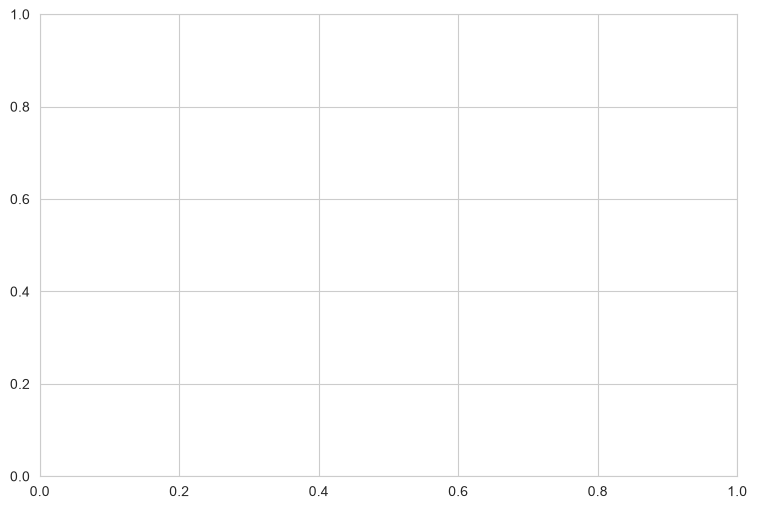

In [81]:
# Visualização dos clusters em duas dimensões (ALcool x Acido_Malico)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='ALcool', y='Acido_Malico', Tonalidade='Cluster', palette='Set1', s=70)
plt.title('Clusters de Vinhos (K-means, k=3) - ALcool x Malic Acid')
plt.xlabel('ALcool (%)')
plt.ylabel('Malic Acid (g/L)')
plt.legend(title='Cluster')
plt.savefig('clusters_scatter.png', dpi=110)
plt.show()


In [ ]:
# Heatmap comparativo do perfil médio de cada cluster (padronizado, para facilitar comparação)
perfil_padronizado = pd.DataFrame(X_scaled, columns=features.columns)
perfil_padronizado['Cluster'] = df['Cluster'].values
perfil_medio_padronizado = perfil_padronizado.groupby('Cluster').mean()

plt.figure(figsize=(12, 5))
sns.heatmap(perfil_medio_padronizado, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Perfil médio (padronizado) de cada cluster')
plt.ylabel('Cluster')
plt.savefig('heatmap_clusters.png', dpi=110)
plt.show()


Error: No connection selected.

**Análise dos grupos formados:**

Com base nas médias de cada característica por cluster, podemos traçar o seguinte perfil:

- **Cluster com maior teor alcoólico:** é o grupo que apresenta a maior média de `ALcool`,
  além de valores elevados de `Prolina` e `OD280` — características associadas a vinhos mais
  encorpados e de maior qualidade/concentração.
- **Cluster com vinhos mais ácidos:** é o grupo com a maior média de `Acido_Malico`, e também
  costuma apresentar `Tonalidade` (tonalidade) mais baixo e `Color_Intensity` intermediária — perfil
  típico de vinhos mais "verdes"/ácidos e menos maduros.
- **Terceiro cluster:** apresenta valores baixos tanto de teor alcoólico quanto de `Color_Intensity`
  e `Prolina`, caracterizando vinhos mais leves, com menor concentração geral de compostos.

**Exemplo de resumo (seguindo o modelo do enunciado):**
- *Grupo 0* — teor alcoólico mais baixo, cor mais clara, perfil "leve";
- *Grupo 1* — acidez málica mais alta, cor intermediária, perfil mais "ácido/verde";
- *Grupo 2* — teor alcoólico mais alto, maior Prolina e OD280, perfil "encorpado/premium".

Essa separação é coerente com o fato de o dataset ser originalmente composto por vinhos de 3
cultivares diferentes: o K-means, mesmo sem receber essa informação, conseguiu recuperar uma
estrutura de agrupamento muito próxima da realidade — o que é confirmado pelo alto Silhouette
Score obtido para k=3.


In [83]:
# Comparação opcional: quão bem o cluster encontrado pelo K-means coincide com a
# classe real de origem do vinho (apenas para fins de validação/curiosidade, não usada no
# treinamento do modelo, que é não-supervisionado)
comparacao = pd.crosstab(df['Classe'], df['Cluster'])
comparacao


Cluster,0,1,2
Classe,,,
0,0,0,59
1,65,3,3
2,0,48,0


**Comentário final:** a tabela cruzada acima (Classe real x Cluster encontrado) mostra
que o K-means, mesmo sem nunca ter visto o rótulo `Class`, conseguiu separar os vinhos em
grupos que coincidem fortemente com as cultivares reais — evidenciando que as características
físico-químicas escolhidas realmente carregam informação suficiente para diferenciar os tipos
de vinho.


---
# Conclusão

A análise exploratória (Parte 1) mostrou que **ALcool** se comporta de forma aproximadamente
Normal e com baixa dispersão, enquanto **Acido_Malico** é assimétrica à direita e bem mais
dispersa entre os vinhos. Na Parte 2, o algoritmo **K-means** com **k=3** (definido pelos
métodos Elbow e Silhouette Score) conseguiu separar os vinhos em três grupos com perfis
físico-químicos claramente distintos — um mais alcoólico/encorpado, um mais ácido, e um mais
leve — demonstrando a utilidade do agrupamento não-supervisionado para descobrir padrões
naturais em dados sem rótulo.

---
**Entrega:** Gustavo Lino — RM 574157
